In [63]:
# ! pip install dtreeviz

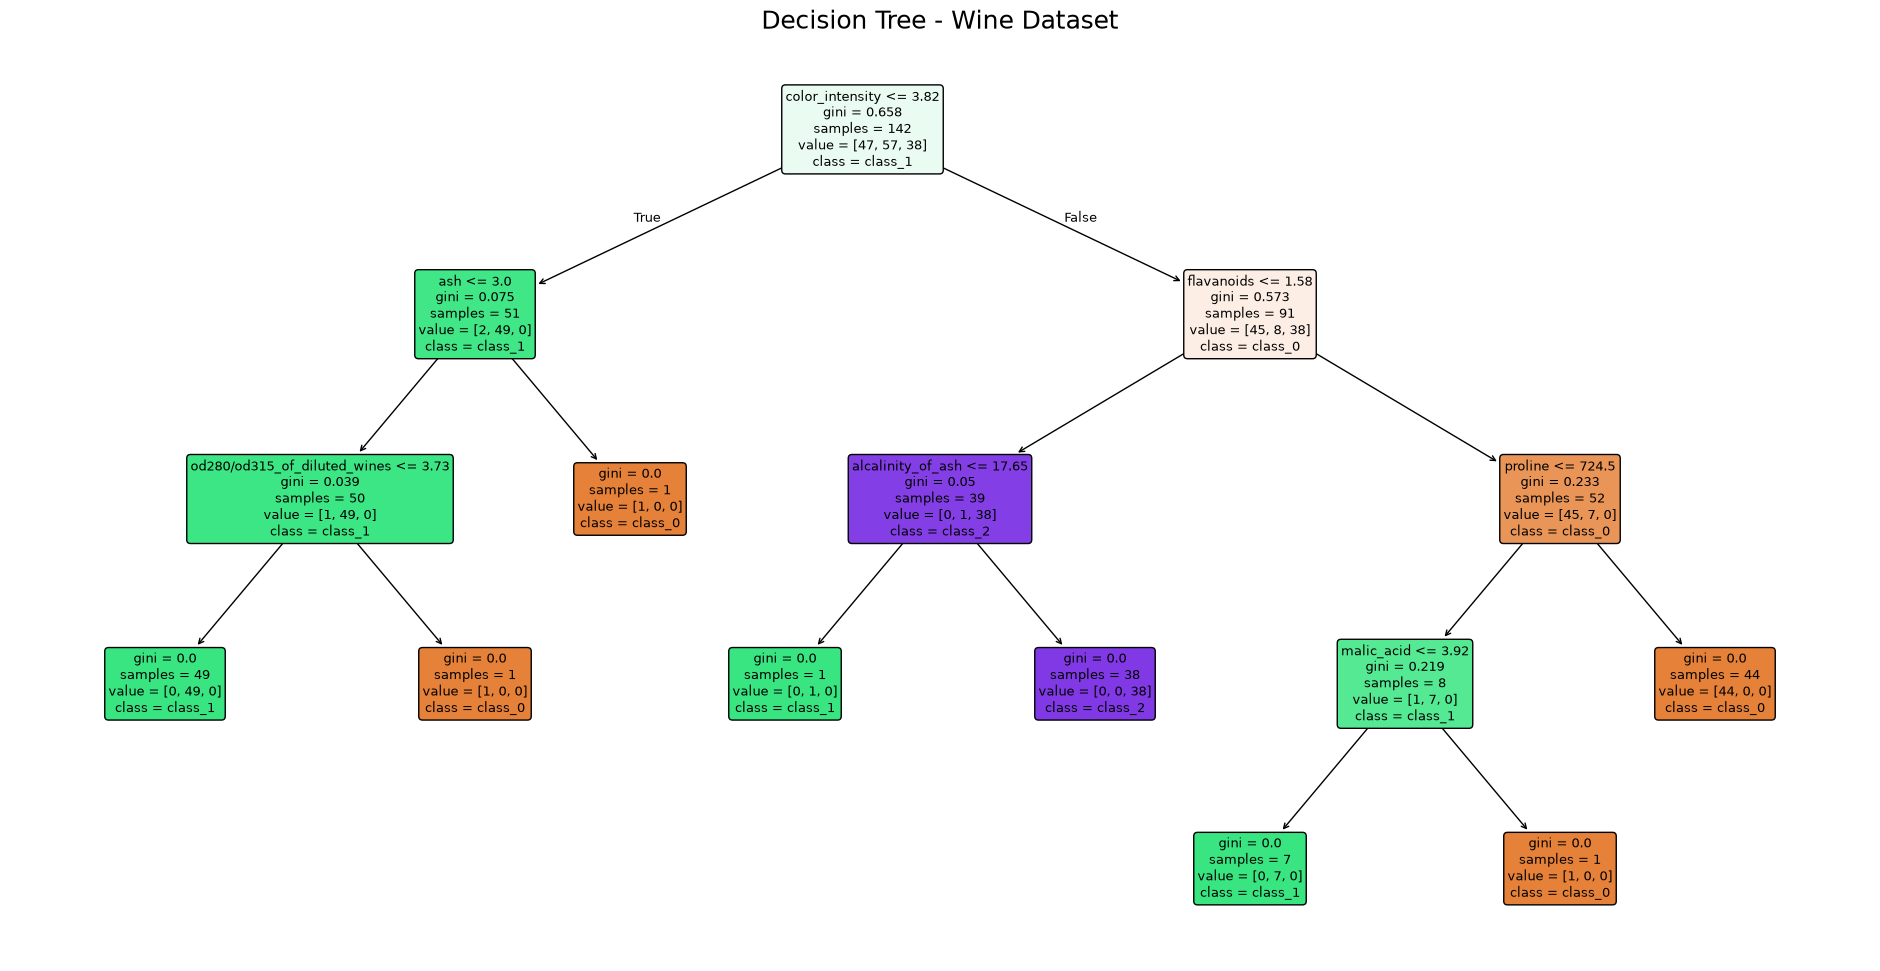

Image Saved Successfully!
Location : output_images/decision_tree_wine.png


In [69]:
# ==========================================
# Import Libraries
# ==========================================

import os
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree

# ==========================================
# Create Output Folder
# ==========================================

os.makedirs("output_images", exist_ok=True)

# ==========================================
# Load Built-in Dataset
# ==========================================

wine = load_wine()

X = wine.data
y = wine.target

# ==========================================
# Train Test Split
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ==========================================
# Train Decision Tree
# ==========================================

model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=4,
    random_state=42
)

model.fit(X_train, y_train)

# ==========================================
# Decision Tree Visualization
# ==========================================

plt.figure(figsize=(24, 12))

plot_tree(
    model,
    feature_names=wine.feature_names,
    class_names=wine.target_names,
    filled=True,
    rounded=True,
    fontsize=9
)

plt.title("Decision Tree - Wine Dataset", fontsize=18)

plt.savefig(
    "output_images/decision_tree_wine.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Image Saved Successfully!")
print("Location : output_images/decision_tree_wine.png")

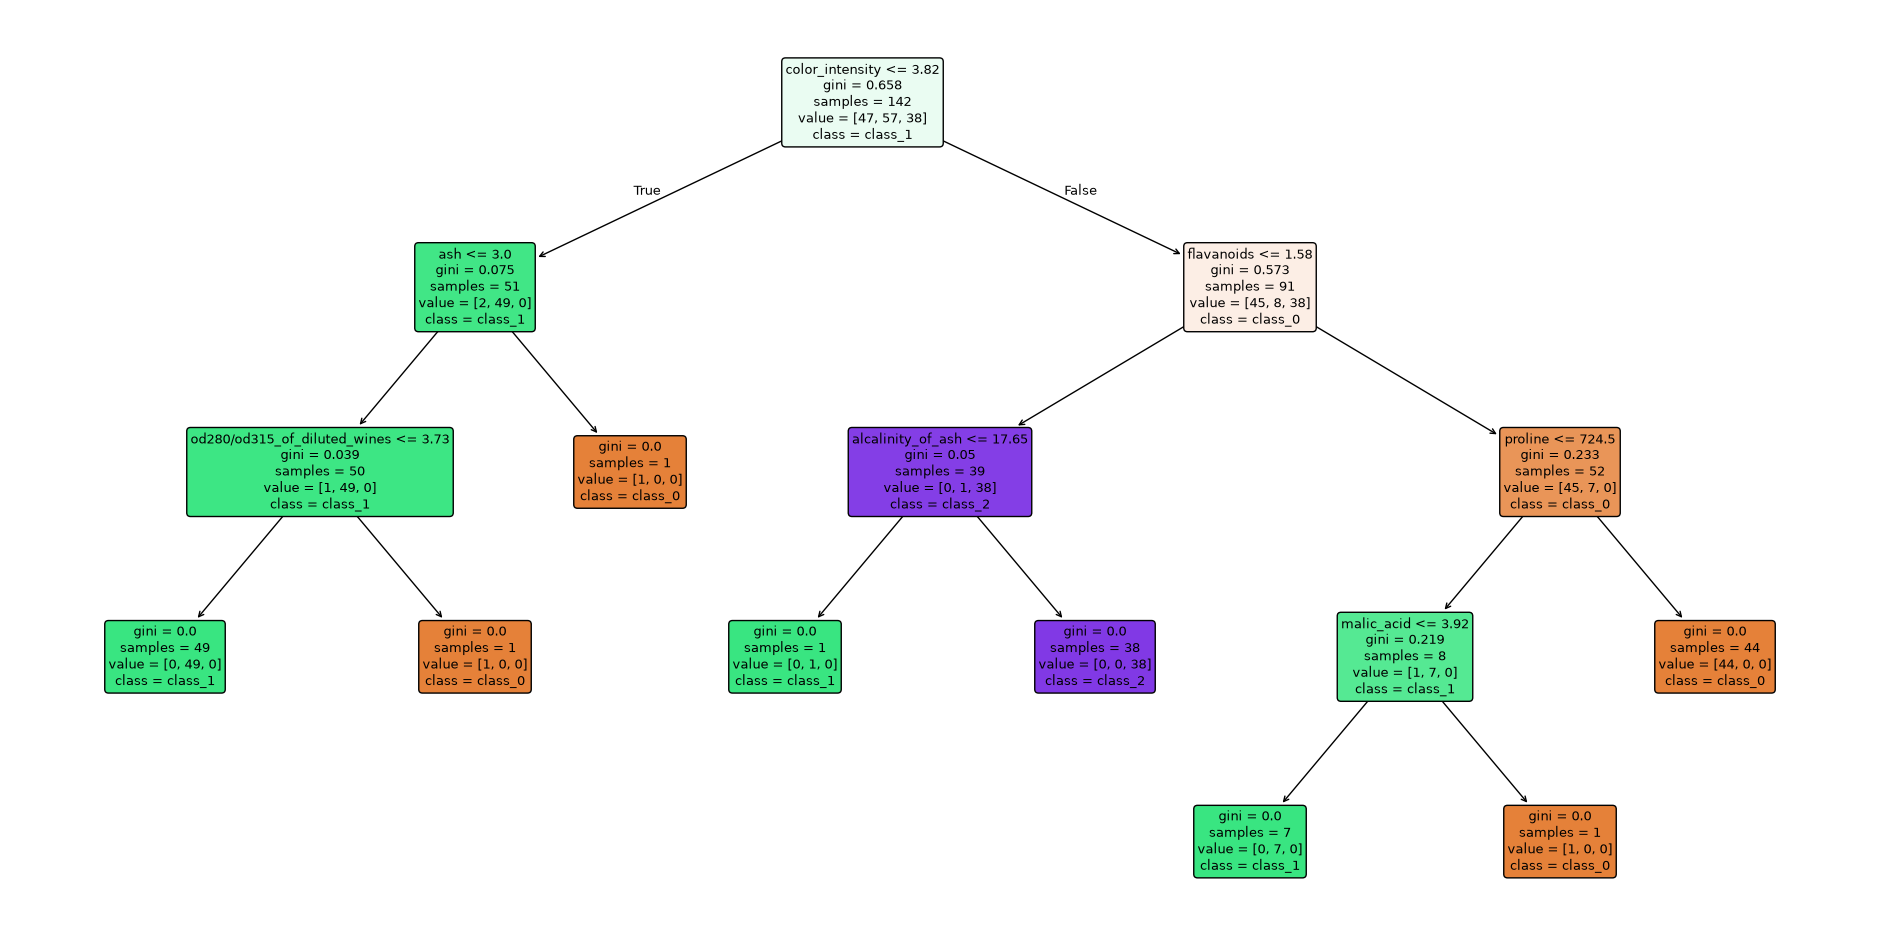

In [70]:
plt.figure(figsize=(24,12))

plot_tree(
    model,
    feature_names=wine.feature_names,
    class_names=wine.target_names,
    filled=True,
    rounded=True,
    fontsize=9
)

plt.savefig("output_images/01_decision_tree.png", dpi=300, bbox_inches="tight")
plt.show()

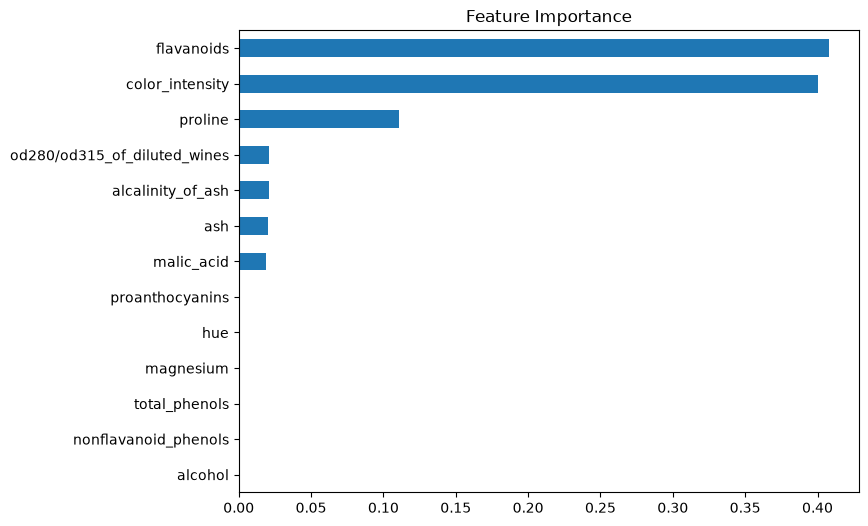

In [71]:
import pandas as pd

importance = pd.Series(
    model.feature_importances_,
    index=wine.feature_names
).sort_values()

plt.figure(figsize=(8,6))

importance.plot(kind="barh")

plt.title("Feature Importance")

plt.savefig("output_images/02_feature_importance.png", dpi=300, bbox_inches="tight")

plt.show()

<Figure size 600x600 with 0 Axes>

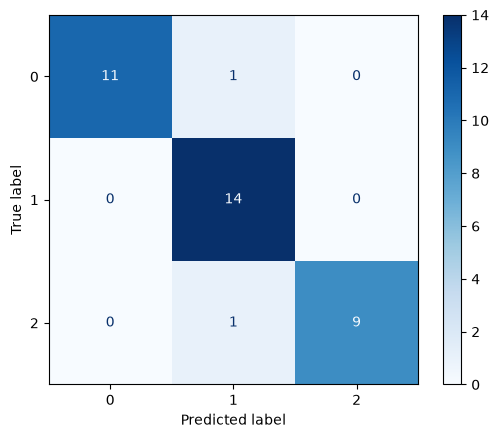

In [72]:
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(6,6))

ConfusionMatrixDisplay.from_estimator(
    model,
    X_test,
    y_test,
    cmap="Blues"
)

plt.savefig("output_images/03_confusion_matrix.png", dpi=300)

plt.show()

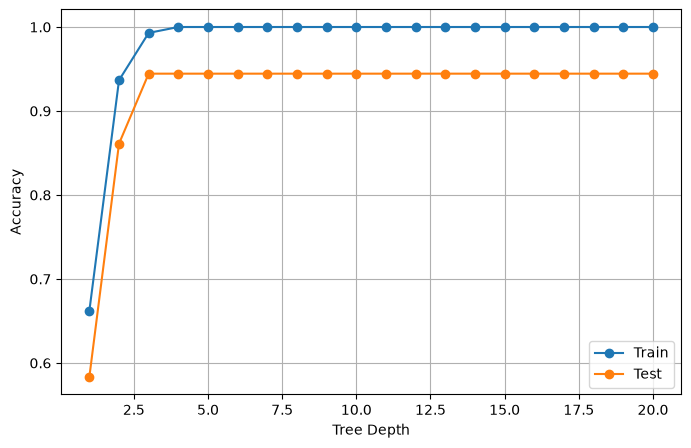

In [73]:
depths = range(1,21)

train_acc=[]
test_acc=[]

for d in depths:

    clf=DecisionTreeClassifier(
        max_depth=d,
        random_state=42
    )

    clf.fit(X_train,y_train)

    train_acc.append(clf.score(X_train,y_train))
    test_acc.append(clf.score(X_test,y_test))

plt.figure(figsize=(8,5))

plt.plot(depths,train_acc,marker="o",label="Train")

plt.plot(depths,test_acc,marker="o",label="Test")

plt.xlabel("Tree Depth")
plt.ylabel("Accuracy")
plt.legend()

plt.grid()

plt.savefig("output_images/04_accuracy_vs_depth.png", dpi=300)

plt.show()

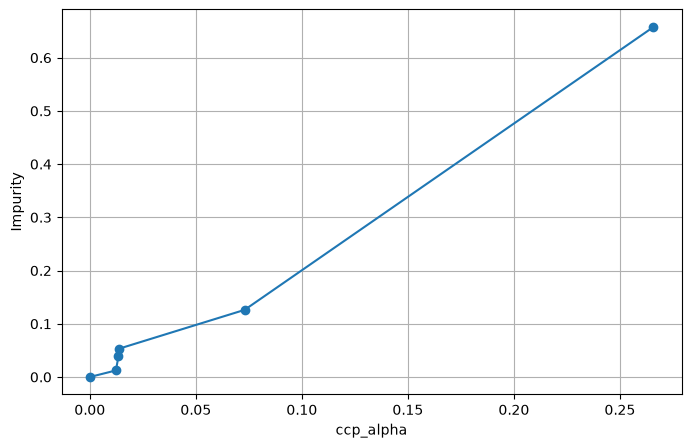

In [74]:
path=model.cost_complexity_pruning_path(
    X_train,
    y_train
)

plt.figure(figsize=(8,5))

plt.plot(
    path.ccp_alphas,
    path.impurities,
    marker="o"
)

plt.xlabel("ccp_alpha")
plt.ylabel("Impurity")

plt.grid()

plt.savefig("output_images/05_pruning_curve.png",dpi=300)

plt.show()

In [76]:
from sklearn.tree import export_text

rules=export_text(
    model,
    feature_names=list(wine.feature_names)
)

print(rules)

with open("output_images/11_decision_rules.txt","w") as f:
    f.write(rules)

|--- color_intensity <= 3.82
|   |--- ash <= 3.00
|   |   |--- od280/od315_of_diluted_wines <= 3.73
|   |   |   |--- class: 1
|   |   |--- od280/od315_of_diluted_wines >  3.73
|   |   |   |--- class: 0
|   |--- ash >  3.00
|   |   |--- class: 0
|--- color_intensity >  3.82
|   |--- flavanoids <= 1.58
|   |   |--- alcalinity_of_ash <= 17.65
|   |   |   |--- class: 1
|   |   |--- alcalinity_of_ash >  17.65
|   |   |   |--- class: 2
|   |--- flavanoids >  1.58
|   |   |--- proline <= 724.50
|   |   |   |--- malic_acid <= 3.92
|   |   |   |   |--- class: 1
|   |   |   |--- malic_acid >  3.92
|   |   |   |   |--- class: 0
|   |   |--- proline >  724.50
|   |   |   |--- class: 0



In [78]:
import numpy as np

sample = X_test[0].reshape(1, -1)

node_indicator = model.decision_path(sample)

leaf_id = model.apply(sample)

print("Leaf Node :", leaf_id)

print("\nDecision Path:")

for node_id in node_indicator.indices:

    if leaf_id[0] == node_id:
        print(f"Leaf Node {node_id}")
    else:
        print(f"Visited Node {node_id}")

Leaf Node : [14]

Decision Path:
Visited Node 0
Visited Node 6
Visited Node 10
Leaf Node 14
